In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

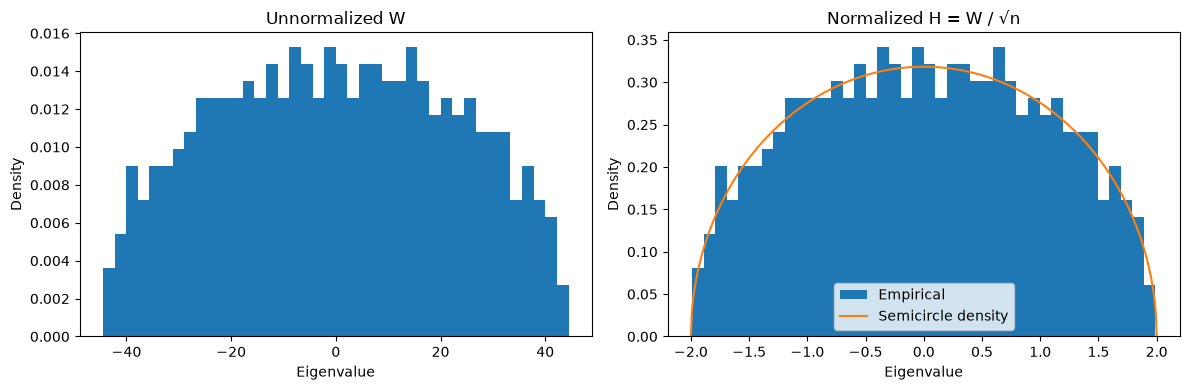

In [3]:
n = 500
rng = np.random.default_rng(42)

# Generate a zero-diagonal Wigner matrix with independent N(0, 1) upper entries
W = np.triu(rng.normal(0, 1, size=(n, n)), k=1)
W = W + W.T

# Normalize by sqrt(n)
H = W / np.sqrt(n)

# Eigenvalues
eig_W = np.linalg.eigvalsh(W)
eig_H = np.linalg.eigvalsh(H)

# Theoretical semicircle density
x = np.linspace(-2, 2, 500)
rho = np.sqrt(4 - x**2) / (2 * np.pi)

# Plot the two eigenvalue histograms
fig, ax = plt.subplots(1, 2, figsize=(12, 4))

ax[0].hist(eig_W, bins=40, density=True)
ax[0].set_title("Unnormalized W")
ax[0].set_xlabel("Eigenvalue")
ax[0].set_ylabel("Density")

ax[1].hist(eig_H, bins=40, density=True, label="Empirical")
ax[1].plot(x, rho, label="Semicircle density")
ax[1].set_title("Normalized H = W / √n")
ax[1].set_xlabel("Eigenvalue")
ax[1].set_ylabel("Density")
ax[1].legend()

plt.tight_layout()
plt.show()

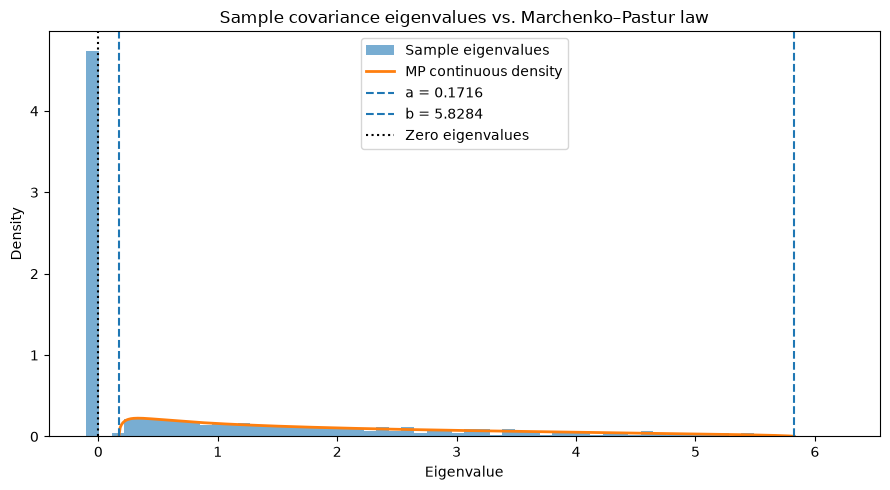

Shape of S: (400, 400)
gamma = 2.0
a = 0.1716, b = 5.8284
Number of zero eigenvalues: 200
Theoretical mass at zero: 0.5


In [4]:
n, m = 400, 200
rng = np.random.default_rng(42)

# Generate iid Gaussian data: 400 variables, 200 observations
X = rng.normal(0, 1, size=(n, m))

# Sample covariance matrix and its eigenvalues
S = X @ X.T / m
eig = np.linalg.eigvalsh(S)

# Marchenko-Pastur parameters
gamma = n / m
sigma2 = 1
a = sigma2 * (1 - np.sqrt(gamma))**2
b = sigma2 * (1 + np.sqrt(gamma))**2

# Continuous MP density
x_mp = np.linspace(a, b, 500)
mp_density = np.sqrt((b - x_mp) * (x_mp - a)) / (
    2 * np.pi * gamma * sigma2 * x_mp
)

# Count eigenvalues numerically equal to zero
num_zero = np.sum(np.isclose(eig, 0, atol=1e-10))

# Plot the empirical eigenvalues and MP density
plt.figure(figsize=(9, 5))
plt.hist(eig, bins=60, range=(-0.1, b + 0.4),
         density=True, alpha=0.6, label="Sample eigenvalues")
plt.plot(x_mp, mp_density, linewidth=2, label="MP continuous density")
plt.axvline(a, linestyle="--", label=f"a = {a:.4f}")
plt.axvline(b, linestyle="--", label=f"b = {b:.4f}")
plt.axvline(0, color="black", linestyle=":", label="Zero eigenvalues")
plt.xlabel("Eigenvalue")
plt.ylabel("Density")
plt.title("Sample covariance eigenvalues vs. Marchenko–Pastur law")
plt.legend()
plt.tight_layout()
plt.show()

print("Shape of S:", S.shape)
print("gamma =", gamma)
print(f"a = {a:.4f}, b = {b:.4f}")
print("Number of zero eigenvalues:", num_zero)
print("Theoretical mass at zero:", max(1 - 1/gamma, 0))

The sample covariance matrix has dimensions \(400\times400\) and exactly 200 zero eigenvalues because the data matrix has rank 200. The aspect ratio is \(\gamma=n/m=2\), giving MP edges \(a\approx0.1716\) and \(b\approx5.8284\), with a theoretical mass of \(0.5\) at zero. The positive eigenvalue distribution approximately follows the continuous MP density. The semicircle law is inappropriate because a covariance matrix is positive semidefinite and its entries are not independent in the manner required by the Wigner model.

In [8]:
n, m = 120, 240
R = 2 * rng.normal(size=(n, m))
X = R - R.mean(axis=1, keepdims=True)
S = X @ X.T / m
eig = np.linalg.eigvalsh(S)
gamma = n / m
sigma2 = 4
a = sigma2 * (1 - np.sqrt(gamma))**2
b = sigma2 * (1 + np.sqrt(gamma))**2

print('correct dimension is', n,'x',n)
print('the correct gamma is', gamma)

correct dimension is 120 x 120
the correct gamma is 0.5


In [10]:
data = pd.read_csv("market_data_2007_2025.csv", parse_dates=["Date"])
data = data.set_index("Date")

prices = data[["SPY_Adj_Close", "QQQ_Adj_Close",
               "TLT_Adj_Close", "HYG_Adj_Close"]]
prices.columns = ["SPY", "QQQ", "TLT", "HYG"]

log_returns = np.log(prices).diff().dropna()
returns_period = log_returns.loc["2018-01-01":"2019-12-31"]

# Standardize each asset using the course's divisor-m convention
means = returns_period.mean(axis=0)
stds = returns_period.std(axis=0, ddof=0)
standardized = (returns_period - means) / stds

# Assets in rows, dates in columns
Z = standardized.T.to_numpy()
m = Z.shape[1]

C = Z @ Z.T / m

print("Shape of Z:", Z.shape)
print("Number of dates:", m)
print("Correlation matrix:\n", C)
print(log_returns)

Shape of Z: (4, 503)
Number of dates: 503
Correlation matrix:
 [[ 1.          0.9455608  -0.34818653  0.80177385]
 [ 0.9455608   1.         -0.29536145  0.76905912]
 [-0.34818653 -0.29536145  1.         -0.20095257]
 [ 0.80177385  0.76905912 -0.20095257  1.        ]]
                 SPY       QQQ       TLT       HYG
Date                                              
2007-04-12  0.004434  0.007886  0.000229  0.000671
2007-04-13  0.004552  0.002018 -0.003095 -0.001821
2007-04-16  0.009451  0.009140  0.005494 -0.000385
2007-04-17  0.002655  0.002217  0.005578 -0.000480
2007-04-18  0.001223 -0.003327  0.004983  0.000288
...              ...       ...       ...       ...
2025-12-24  0.003512  0.002921  0.006039  0.001862
2025-12-26 -0.000101 -0.000064 -0.003300 -0.000496
2025-12-29 -0.003570 -0.004852  0.003754  0.000372
2025-12-30 -0.001222 -0.002322 -0.002387  0.000992
2025-12-31 -0.007437 -0.008300 -0.007999 -0.000992

[4712 rows x 4 columns]


In [15]:
# Select daily log returns for 2018–2019
returns_period = log_returns.loc["2018-01-01":"2019-12-31"]

# Assets in rows, dates in columns
R = returns_period.T.to_numpy()
n, m = R.shape

# Standardize each asset across its dates
means = R.mean(axis=1, keepdims=True)
stds = R.std(axis=1, ddof=0, keepdims=True)
Z = (R - means) / stds

# Sample correlation matrix
C = Z @ Z.T / m

print("Shape of R:", R.shape)
print("Shape of Z:", Z.shape)
print("Shape of C:", C.shape)
print(C)

Shape of R: (4, 503)
Shape of Z: (4, 503)
Shape of C: (4, 4)
[[ 1.          0.9455608  -0.34818653  0.80177385]
 [ 0.9455608   1.         -0.29536145  0.76905912]
 [-0.34818653 -0.29536145  1.         -0.20095257]
 [ 0.80177385  0.76905912 -0.20095257  1.        ]]


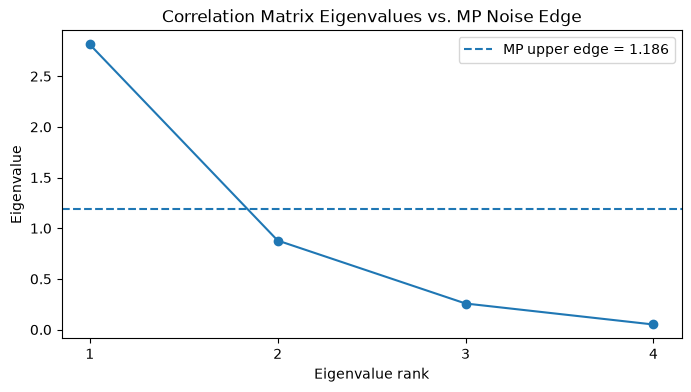

In [16]:
eig = np.linalg.eigvalsh(C)[::-1]

gamma = 4 / m
b = (1 + np.sqrt(gamma))**2

plt.figure(figsize=(8, 4))
plt.plot(np.arange(1, 5), eig, marker="o")
plt.axhline(b, linestyle="--", label=f"MP upper edge = {b:.3f}")
plt.xlabel("Eigenvalue rank")
plt.ylabel("Eigenvalue")
plt.title("Correlation Matrix Eigenvalues vs. MP Noise Edge")
plt.xticks(np.arange(1, 5))
plt.legend()
plt.show()